<a href="https://colab.research.google.com/github/jad-r-s/Jad_INFO4670_Fall2026/blob/main/JadSaboune_INFO4670_Week3_Assignment1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1 — Making Sense of Northgate through Visualization
**INFO 4670 · Data Analysis and Knowledge Discovery**  ·  **Due: Sunday, 11:59 PM**

**Name:** Jad Saboune    **Date:** 9/6/2026

**The situation.** The Provost's question stands: *which students are struggling, and can we see it earlier?* This week you answer it the way analysts do — not by reading rows, but by drawing the data. Every chart below is built by **adapting code from the Guided notebook**; the intellectual work is choosing the right chart and reading it honestly.

**For every chart you make, you must:**
1. **Choose** the chart type that fits the variable(s) and the question.
2. **Build** it in Colab from the Northgate files.
3. **Label** it fully — title, axis labels, and units/legend. *An unlabeled chart is an unfinished chart.*
4. **Write a STAR story** underneath it — Scope · Track · Articulate · Respond (defined on the Concepts deck).

**How to work:** run Setup and Load first. Then, for each question, copy the closest cell from the Guided notebook into the empty cell, adapt it, and fill in the STAR cell below it.

**Submit:** push this notebook to GitHub and submit the **GitHub link** in Canvas. (See the setup doc: *Colab_GitHub_Setup_INFO4670_Fall2026*.)

## Setup — run this first (you don't need to change it)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Northgate house style (optional, but keeps your charts consistent)
NAVY = "#22303A"
RUST = "#C0562F"
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]   = (8, 5)
plt.rcParams["axes.titlesize"]   = 13
plt.rcParams["axes.titleweight"] = "bold"

## Load the data — run this, then look before you plot

In [3]:
# STEP 1 — get the data into this notebook. Pick ONE option, then run.

DATA_DIR = "."   # OPTION 2 (default) · drag the 3 CSVs into the file panel on the left

# OPTION 1 · read from Google Drive — uncomment and edit the path:
# from google.colab import drive
# drive.mount("/content/drive")
# DATA_DIR = "/content/drive/MyDrive/.../Data"

import os
students = pd.read_csv(os.path.join(DATA_DIR, "student_records.csv"))
weekly   = pd.read_csv(os.path.join(DATA_DIR, "weekly_activity.csv"))
students.head()

,student_id,major,age,housing,commute_miles,work_hours_per_week,advisor_meetings,credits_attempted,final_gpa,study_hours_reported,enrollment_date,dropped_out
0,NU-101508,Data Science,27,Off-Campus,7.6,15,1,81,1.86,NaN,2023-09-13,1
1,NU-102438,Learning Technologies,25,With Family,14.3,35,1,100,2.06,9.5,2023-10-19,0
2,NU-102385,Learning Technologies,26,With Family,3.4,18,9,77,3.41,19.1,11/16/2022,0
3,NU-100767,Cyber Security,22,On-Campus,23.7,40,1,65,1.73,8.1,2024-05-03,0
4,NU-106054,Information Technology,21,Off-Campus,2.3,20,4,59,2.37,6.6,10/24/2022,0


In [4]:
# how many rows, which columns, what types?
students.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2027 entries, 0 to 2026
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            2027 non-null   object 
 1   major                 2027 non-null   object 
 2   age                   2027 non-null   int64  
 3   housing               2027 non-null   object 
 4   commute_miles         2027 non-null   float64
 5   work_hours_per_week   2027 non-null   int64  
 6   advisor_meetings      2027 non-null   int64  
 7   credits_attempted     2027 non-null   int64  
 8   final_gpa             2027 non-null   float64
 9   study_hours_reported  1772 non-null   float64
 10  enrollment_date       2027 non-null   object 
 11  dropped_out           2027 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 190.2+ KB


# Part A — Guided questions
Build **one chart per question**. Each maps to one chart family from this week. Copy the closest Guided-notebook cell, adapt it, label it, then write its STAR story.

### Q1 · One quantitative variable
**How many hours per week do Northgate students work?** Describe what's typical, how spread out it is, and whether anyone stands apart.
→ *histogram* (add a *box plot* if it helps). Column: `work_hours_per_week` (from `students`).

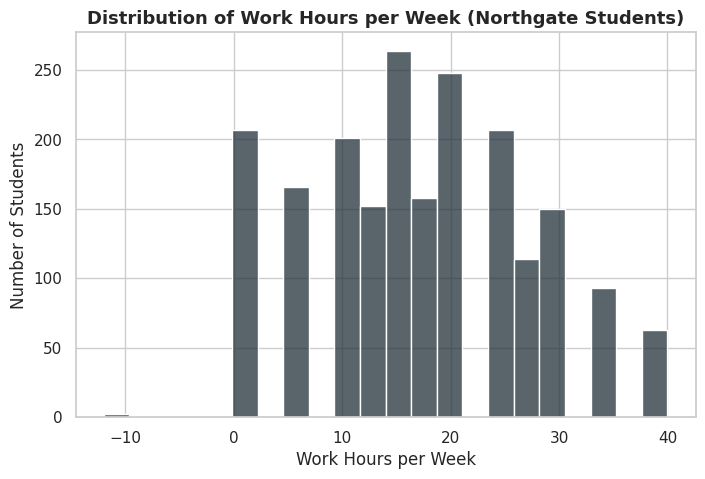

In [7]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()
sns.histplot(data=students, x="work_hours_per_week", color=NAVY, ax=ax)
ax.set_title("Distribution of Work Hours per Week (Northgate Students)")
ax.set_xlabel("Work Hours per Week")
ax.set_ylabel("Number of Students")
plt.show()

**STAR story — Q1** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

This chart shows the work_hours_per_week column from the students dataset. One bar per weekly-hours bucket, counting how many Northgate students fall into each.

- **Track —** which question are you answering?

How many hours per week do Northgate students typically work, and how much does that vary?

- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

The distribution is roughly spread across 0-40 hours, with the bulk of students clustering between 10 and 25 hours per week.The tallest bars are around 15-20 hours, which looks like the typical range. The shape isn't a clean bell curve, it is multi-peaked, and it tapers off gradually above 25 hours.

- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

The odd thing that jumps out is the small bar around -10 hours. A negative value for "hours worked" isn't possible, so that's certainly a data-entry or data cleaning issue. I'd flag it rather than fix it this week, and next I'd check to see how many rows are affected and whether the same students have other suspicious values.

### Q2 · One categorical variable
**How does enrollment compare across majors?**
→ *sorted bar chart*. Column: `major` (from `students`).

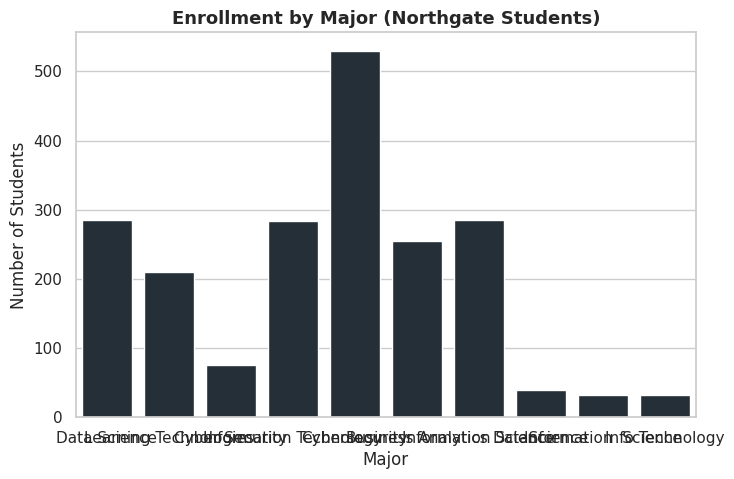

In [12]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()
sns.countplot(data=students, x="major", color=NAVY, ax=ax)
ax.set_title("Enrollment by Major (Northgate Students)")
ax.set_xlabel("Major")
ax.set_ylabel("Number of Students")
plt.show()

**STAR story — Q2** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

This chart shows the major column from the students table, counting the number of Northgate students enrolled in each major.

- **Track —** which question are you answering?

How are students distributed across majors and which majors are most and least popular?

- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

Information Technology is by far the largest group at over 500 students, roughly double most of the other majors. Data Science, Cyber Security, Business Analytics, and Information Science each sit in a similar mid-size band of around 250–285 students, while Learning Technologies is smaller at around 210. A few categories trail far behind with under 40 students each.

- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

The clear issue here is that several bars are actually the same major split across inconsistent spellings/formatting, "Cybersecurity" vs. "Cyber Security," "DataScience" vs. "Data Science," "Information Science" appearing twice (likely differing in capitalization or spacing), and "Info Technology" vs. "Information Technology." This is a text-standardization problem, not a real reflection of 11 distinct majors. Next, I'd look at the raw unique values in the major column and build a mapping to consolidate these duplicates before trusting any counts, this week I'm just flagging it, not fixing it.


### Q3 · A quantity, split by category
**Does final GPA differ across majors?** Read the exceptions, not just the boxes.
→ *box plot per major*. Columns: `final_gpa` and `major` (from `students`).

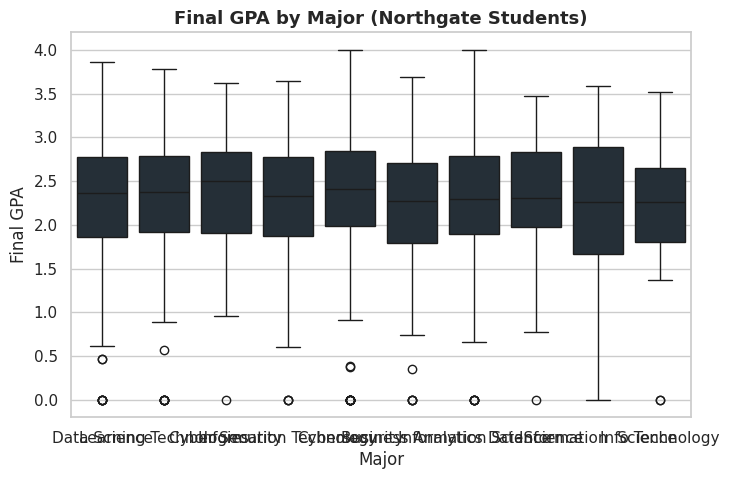

In [16]:
from matplotlib.figure import figaspect
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()
sns.boxplot(data=students, x="major", y="final_gpa", color=NAVY, ax=ax)
ax.set_title("Final GPA by Major (Northgate Students)")
ax.set_xlabel("Major")
ax.set_ylabel("Final GPA")
plt.show()

**STAR story — Q3** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

This shows final_gpa from the students table, split into a seperate box plot for each major.

- **Track —** which question are you answering?

Does final GPA differ across majors?

- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

Medians are all clustered tightly between roughly 2.25 and 2.5, and the boxes (middle 50% of students) overlap heavily across every major. So major-to-major, the typical student's GPA looks basically the same, there's no major that clearly outperforms or underperforms the others. Spread within each major is also similar, generally spanning about 1.9 to 2.8 for the middle half of students, with whiskers reaching up near 3.5–4.0 at the high end.

- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

The outliers are the real finding here, not the medians. Every single major has a group of students sitting at exactly 0.0 GPA, which shows up as a stack of open-circle outliers at the bottom of each box. A true 0.0 final GPA is unusual enough, and consistent enough across every category, that it looks like a placeholder value rather than a genuine grade. I'd also note the x-axis labels are overlapping/garbled in this render, and the major categories still have the duplicate-spelling issue from before, so the "10 majors" shown aren't all distinct. Next, I'd check whether the 0.0 GPA rows line up with dropped_out = 1 before treating them as real performance data, and clean up the major labels so the comparison is apples-to-apples.

### Q4 · Two quantitative variables
**Is there a relationship between how far students commute and their final GPA?** Remember: *association is not causation.*
→ *scatterplot with a trend line*. Columns: `commute_miles` and `final_gpa` (from `students`).

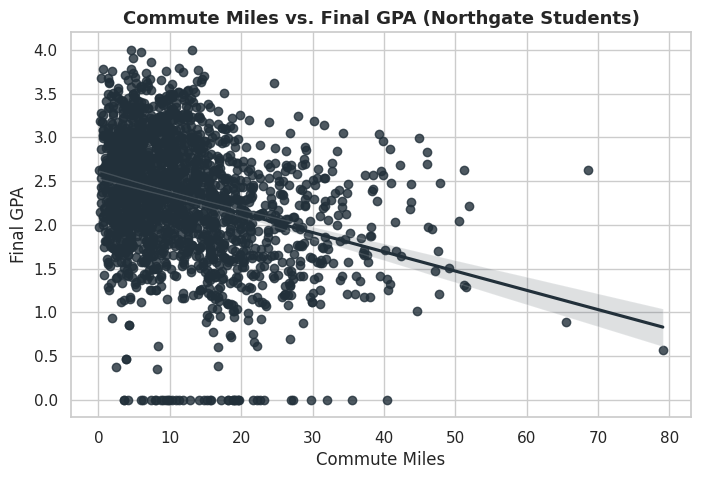

In [17]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
fig, ax = plt.subplots()
sns.regplot(data=students, x="commute_miles", y="final_gpa", color=NAVY, ax=ax)
ax.set_title("Commute Miles vs. Final GPA (Northgate Students)")
ax.set_xlabel("Commute Miles")
ax.set_ylabel("Final GPA")
plt.show()

**STAR story — Q4** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

This shows commute_miles plotted against final_gpa for each student in the students table, with a fitted trend line.

- **Track —** which question are you answering?

Does commute distance relate to academic performance (final GPA)?

- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

Most students commute short distances — the bulk of points sit under about 20 miles — and there's a mild negative trend: as commute miles increase, final GPA tends to drift downward. The scatter is wide at short commutes (students with a 5-mile commute range from GPA 0 to 4.0), so commute distance is clearly not the only thing driving GPA.

- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

Two things stand out. First, there's a row of points sitting exactly on GPA = 0.0 stretching across almost the entire commute range, same suspicious placeholder pattern seen in the last two charts, and it doesn't seem tied to how far a student commutes. Second, a handful of students with very long commutes (60–80 miles) sit at low-to-moderate GPAs with no 4.0-range outliers up there, which is consistent with the downward trend but is based on very few points, so that end of the line is much less reliable. Next, I'd re-run this relationship after excluding the 0.0 GPA rows (once I understand what they represent) to see if the negative trend holds or is partly an artifact of those placeholder values.

### Q5 · Over time
**How does student engagement change across the semester?**
→ *line chart* of average weekly activity. Use the `weekly` table: `week` and `minutes_active` (you'll need to average by week first — see the Guided notebook).

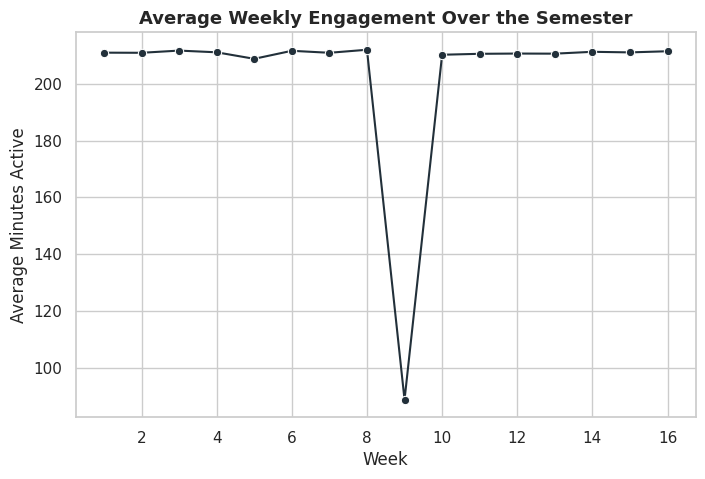

In [9]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
weekly_avg = weekly.groupby("week", as_index=False)["minutes_active"].mean()

fig, ax = plt.subplots()
sns.lineplot(data=weekly_avg, x="week", y="minutes_active", color=NAVY, ax=ax, marker="o")
ax.set_title("Average Weekly Engagement Over the Semester")
ax.set_xlabel("Week")
ax.set_ylabel("Average Minutes Active")
plt.show()

**STAR story — Q5** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

This chart shows minutes_active from the weekly_activity table, averaged across all students for each week of the semester (weeks 1-16).

- **Track —** which question are you answering?

How does student engagement change over the course of the semester?

- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

Engagement is essentially flat and stable, the average minutes active hovers right around 210 minutes almost every single week, with no meaningful upward or downward trend across the 16 weeks. There's no evidence of students gradually disengaging or engaging more as the semester progresses.

- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

The one clear anomaly is week 9, where the average plunges to about 89 minutes and snaps right back to ~210 the very next week. Because it's a single-week spike down rather than part of a trend, it's more likely a data or calendar artifact than a genuine drop in student engagement. Next, I'd check the academic calendar for week 9 and look at whether the drop is uniform across all students or concentrated in a subset, before treating it as a real signal.

# Part B — Your own question (open)
Pose **one question of your own** about the Northgate students, choose the chart that answers it, build it, label it, and write its STAR story. Going beyond Part A is rewarded — a per-student line chart, a violin plot, or a chart of a messier column are all fair game.

**Your question:** Do students who drop out have fewer advisor meetings than students who stay enrolled?



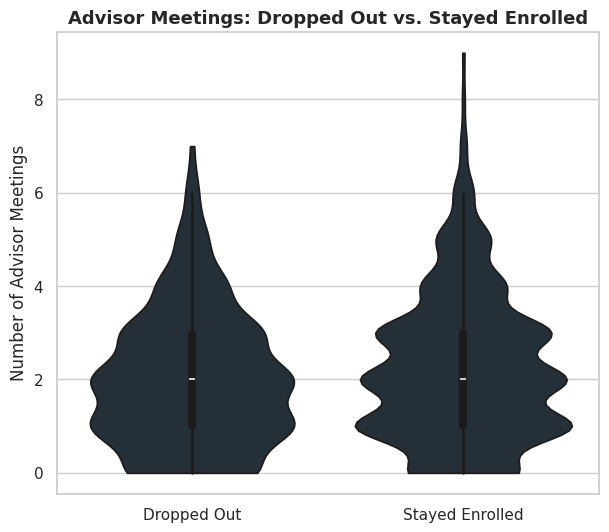

In [18]:
# Copy the closest cell from the Guided notebook, then fill in the blanks.
#
#   fig, ax = plt.subplots()
#   sns.__________(data=________, x="__________", color=NAVY, ax=ax)   # which chart? which column(s)?
#   ax.set_title("__________")
#   ax.set_xlabel("__________")
#   ax.set_ylabel("__________")
#   plt.show()

# --- your code below ---
students["dropout_label"] = students["dropped_out"].map({0: "Stayed Enrolled", 1: "Dropped Out"})

fig, ax = plt.subplots(figsize=(7, 6))
sns.violinplot(data=students, x="dropout_label", y="advisor_meetings", color=NAVY, ax=ax, cut=0)
ax.set_title("Advisor Meetings: Dropped Out vs. Stayed Enrolled")
ax.set_xlabel("")
ax.set_ylabel("Number of Advisor Meetings")
plt.show()

**STAR story — Part B** *(write in your own words)*

- **Scope —** what does this chart show? (which column(s), which students)

This shows advisor_meetings from the students table, split into two groups by dropped_out status: students who left versus students who stayed enrolled.

- **Track —** which question are you answering?

The question is whether dropped-out students had fewer advisor meetings than students who stayed, i.e., could low advisor contact be an early warning sign for leaving?

- **Articulate —** what does the chart actually say? (typical value, spread, shape, comparison, or trend)

The two distributions are nearly identical. Both groups have a median of exactly 2 advisor meetings, and the overall shape — widest around 1–3 meetings, tapering off toward 0 on one side and higher counts on the other, matches closely between the two. The only visible difference is that "Stayed Enrolled" has a slightly longer tail, reaching up to 9 meetings versus a max of 7 for "Dropped Out," but that's a small difference at the extreme edge, not a shift in the bulk of the data.

- **Respond —** anything odd or unexpected? what would you look at next? *(note it — you don't fix it this week)*

I expected students who dropped out to show visibly fewer advisor touchpoints, and they don't. That suggests advisor-meeting count by itself isn't a strong predictor of dropout, at least not in this raw form. A likely explanation is that the column doesn't capture timing: a student could have met with an advisor several times right up until the semester they left, so the total count looks normal even though the relationship with the advisor didn't prevent the outcome. Next, I'd want to see whether meeting dates are available to check if meetings dropped off right before a student left, and I'd also compare dropped_out against other variables to see if something else separates the two groups more clearly than this one does.

# Before you submit — checklist
- [ ] The notebook **runs top to bottom** with no errors (Runtime → Restart and run all).
- [ ] All **6 charts** are present, each with a title, labeled axes, and units/legend where needed.
- [ ] Each chart has a **complete STAR story**, including any exceptions you spotted.
- [ ] Part B question is written in and answered.
- [ ] Pushed to **GitHub**, and the **GitHub link** is submitted in Canvas.

**Rubric (70 pts):** chart choice 10 · correct build 20 · labeling 10 · STAR reading 18 · Part B question 4 · submission & professionalism 8.